In [ ]:
# Weather Station Analysis — AICC 170 (Intro to Data Mining and Analytics), Spring 2026
# Elijah Walker
#
# Connects to MariaDB if credentials are set in the environment; otherwise builds a
# local SQLite database from weather_readings.csv so the notebook runs anywhere.
# The SQL in every cell is identical either way.

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine

if os.getenv("MARIADB_USER"):
    USER = os.environ["MARIADB_USER"]
    PASSWORD = os.environ["MARIADB_PASSWORD"]
    HOST = os.environ.get("MARIADB_HOST", "localhost")
    PORT = os.environ.get("MARIADB_PORT", "3306")
    DB = os.environ["MARIADB_DB"]
    engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}")
else:
    engine = create_engine("sqlite:///weather.db")
    pd.read_csv("weather_readings.csv").to_sql("weather_readings", engine, if_exists="replace", index=False)

# --- Test connection ---
df_test = pd.read_sql("SELECT COUNT(*) AS total FROM weather_readings", engine)
print(df_test)


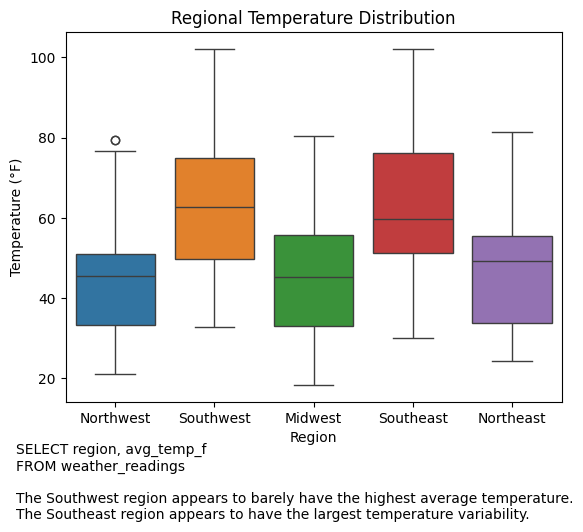

In [2]:
# --- Question 1 ---
# --- Regional Temperature Distribution ---
df_rtd = pd.read_sql("""
                     SELECT region, avg_temp_f
                     FROM weather_readings
                     """, engine)
sns.boxplot(data=df_rtd, x="region", y="avg_temp_f", hue='region', legend=False)

plt.title("Regional Temperature Distribution")
plt.xlabel("Region")
plt.ylabel("Temperature (°F)")
plt.text(x=-1, y=-15, s="SELECT region, avg_temp_f\n"
         "FROM weather_readings\n\n"
         "The Southwest region appears to barely have the highest average temperature.\n"
         "The Southeast region appears to have the largest temperature variability.")
plt.savefig("plots/question_1.png", bbox_inches='tight')
plt.show()

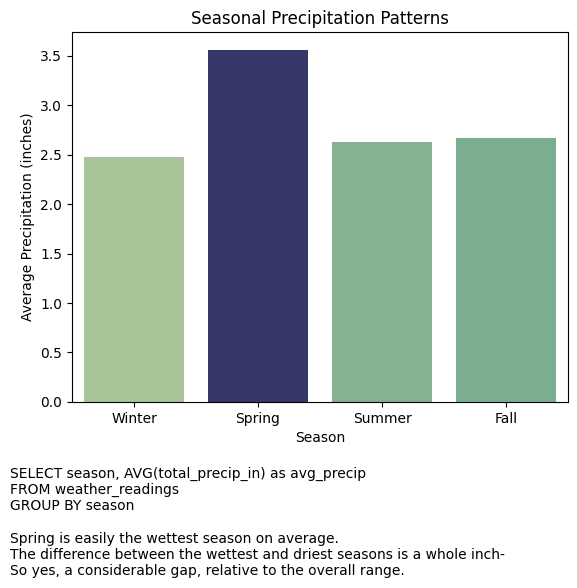

In [3]:
# --- Question 2 ---
# --- Seasonal Precipitation Patterns ---
df_spp = pd.read_sql("""
                     SELECT season, AVG(total_precip_in) as avg_precip
                     FROM weather_readings GROUP BY season
                     """, engine)
sns.barplot(data=df_spp, x="season", y="avg_precip", palette='crest', hue='avg_precip', order=["Winter", "Spring", "Summer", "Fall"], legend=False)

plt.title("Seasonal Precipitation Patterns")
plt.xlabel("Season")
plt.ylabel("Average Precipitation (inches)")
plt.text(x=-1, y=-1.75, s="SELECT season, AVG(total_precip_in) as avg_precip\n"
         "FROM weather_readings\n"
         "GROUP BY season\n\n"
         "Spring is easily the wettest season on average.\n"
         "The difference between the wettest and driest seasons is a whole inch-\n"
         "So yes, a considerable gap, relative to the overall range.")
plt.savefig("plots/question_2.png", bbox_inches='tight')
plt.show()

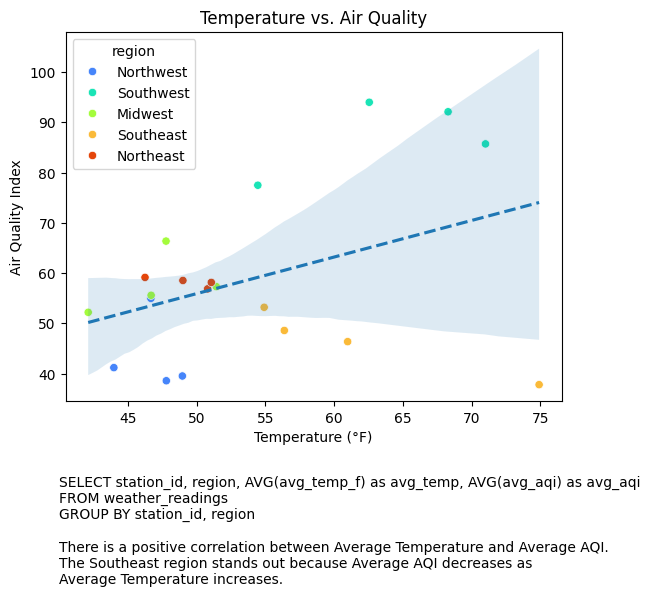

In [23]:
# --- Question 3 ---
# --- Temperature vs. Air Quality ---
df_taq = pd.read_sql("""
                     SELECT station_id, region, AVG(avg_temp_f) as avg_temp, AVG(avg_aqi) as avg_aqi
                     FROM weather_readings
                     GROUP BY station_id, region
                     """, engine)  # what a mouthful.
sns.scatterplot(data=df_taq, x="avg_temp", y="avg_aqi", palette='turbo', hue='region', legend=True)
sns.regplot(data=df_taq, x="avg_temp", y="avg_aqi", scatter=False, line_kws={"linestyle": "--"})

plt.title("Temperature vs. Air Quality")
plt.xlabel("Temperature (°F)")
plt.ylabel("Air Quality Index")
plt.text(x=40, y=-5, s="""
SELECT station_id, region, AVG(avg_temp_f) as avg_temp, AVG(avg_aqi) as avg_aqi
FROM weather_readings
GROUP BY station_id, region
                     
There is a positive correlation between Average Temperature and Average AQI.
The Southeast region stands out because Average AQI decreases as
Average Temperature increases.
                     """)
plt.savefig("plots/question_3.png", bbox_inches='tight')
plt.show()

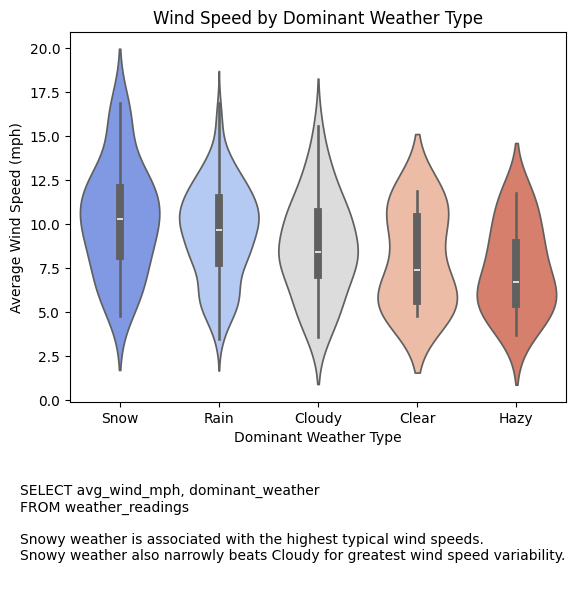

In [42]:
# --- Question 4 ---
# --- Wind Speed by Dominant Weather Type ---
df_wsw = pd.read_sql("""
                     SELECT avg_wind_mph, dominant_weather
                     FROM weather_readings
                     """, engine)
sns.violinplot(data=df_wsw, x="dominant_weather", y="avg_wind_mph", palette='coolwarm', hue='dominant_weather', legend=False)

plt.title("Wind Speed by Dominant Weather Type")
plt.xlabel("Dominant Weather Type")
plt.ylabel("Average Wind Speed (mph)")
plt.text(x=-1, y=-10, s="""
SELECT avg_wind_mph, dominant_weather
FROM weather_readings
                     
Snowy weather is associated with the highest typical wind speeds.
Snowy weather also narrowly beats Cloudy for greatest wind speed variability.
                     """)
plt.savefig("plots/question_4.png", bbox_inches='tight')
plt.show()

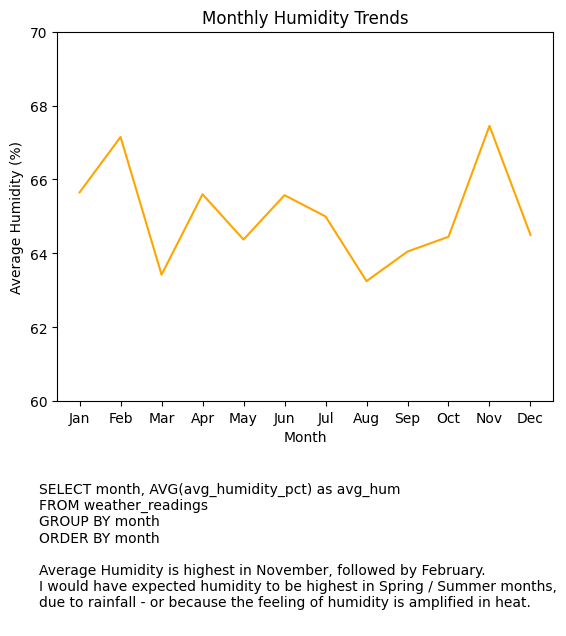

In [90]:
# --- Question 5 ---
# --- Monthly Humidity Trends ---
df_mht = pd.read_sql("""
                     SELECT month, AVG(avg_humidity_pct) as avg_hum
                     FROM weather_readings
                     GROUP BY month
                     ORDER BY month
                     """, engine)
sns.lineplot(data=df_mht, x="month", y="avg_hum", color='orange')

plt.title("Monthly Humidity Trends")
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                           "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.ylim(60, 70)
plt.xlabel("Month")
plt.ylabel("Average Humidity (%)")
plt.text(x=0, y=54, s="""
SELECT month, AVG(avg_humidity_pct) as avg_hum
FROM weather_readings
GROUP BY month
ORDER BY month

Average Humidity is highest in November, followed by February.
I would have expected humidity to be highest in Spring / Summer months,
due to rainfall - or because the feeling of humidity is amplified in heat.
                     """)
plt.savefig("plots/question_5.png", bbox_inches='tight')
plt.show()

/var/folders/y2/79gjt_nj5q14ndrck4bvm76r0000gn/T/ipykernel_16898/839159685.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_aqr, x="region", y="highs", palette='hot')  # ha


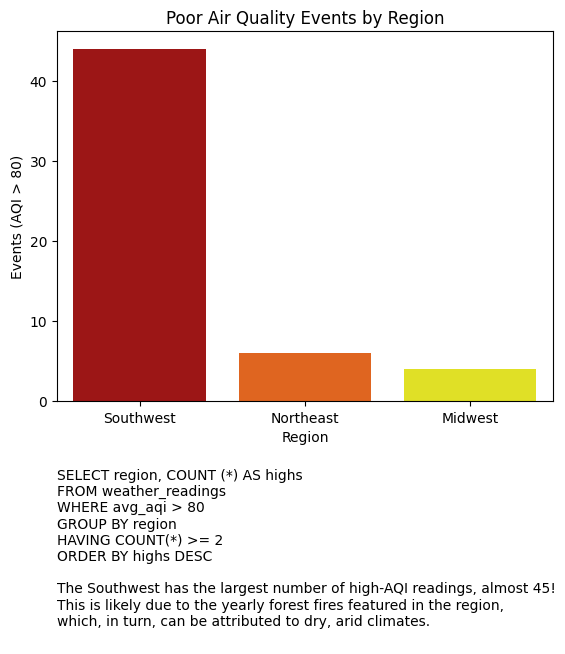

In [114]:
# --- Question 6 ---
# --- Poor Air Quality Events by Region ---
df_aqr = pd.read_sql("""
                     SELECT region, COUNT(*) AS highs
                     FROM weather_readings
                     WHERE avg_aqi > 80
                     GROUP BY region
                     HAVING COUNT(*) >= 2
                     ORDER BY highs DESC
                     """, engine)
sns.barplot(data=df_aqr, x="region", y="highs", palette='hot')  # ha

plt.title("Poor Air Quality Events by Region")
plt.xlabel("Region")
plt.ylabel("Events (AQI > 80)")
plt.text(x=-.5, y=-30, s="""
SELECT region, COUNT (*) AS highs
FROM weather_readings
WHERE avg_aqi > 80
GROUP BY region
HAVING COUNT(*) >= 2
ORDER BY highs DESC

The Southwest has the largest number of high-AQI readings, almost 45!
This is likely due to the yearly forest fires featured in the region,
which, in turn, can be attributed to dry, arid climates.
                     """)
plt.savefig("plots/question_6.png", bbox_inches='tight')
plt.show()

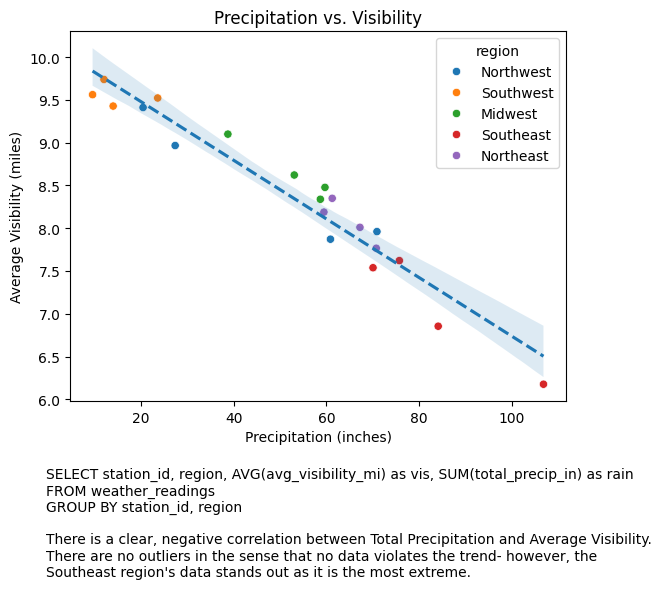

In [131]:
# --- Question 7 ---
# --- Precipitation vs. Visibility ---
df_pvv = pd.read_sql("""
                     SELECT station_id, region, AVG(avg_visibility_mi) as vis, SUM(total_precip_in) as rain
                     FROM weather_readings
                     GROUP BY station_id, region
                     """, engine)
sns.scatterplot(data=df_pvv, x="rain", y="vis", hue='region')
sns.regplot(data=df_pvv, x="rain", y="vis", scatter=False, line_kws={"linestyle": "--"})

plt.title("Precipitation vs. Visibility")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Average Visibility (miles)")
plt.text(x=-.5, y=3.75, s="""
SELECT station_id, region, AVG(avg_visibility_mi) as vis, SUM(total_precip_in) as rain
FROM weather_readings
GROUP BY station_id, region

There is a clear, negative correlation between Total Precipitation and Average Visibility.
There are no outliers in the sense that no data violates the trend- however, the 
Southeast region's data stands out as it is the most extreme.
                     """)
plt.savefig("plots/question_7.png", bbox_inches='tight')
plt.show()